### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)


In [4]:
import arxiv as arxiv_lib
from langchain_core.tools import tool

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [5]:
_arxiv_client = arxiv_lib.Client()

@tool
def arxiv(query: str) -> str:
    """Search arxiv.org for academic papers on a topic and return each paper's title, authors, publish date and summary."""
    papers = _arxiv_client.results(arxiv_lib.Search(query=query, max_results=2))
    results = []
    for p in papers:
        results.append(
            f"Published: {p.published.date()}\n"
            f"Title: {p.title}\n"
            f"Authors: {', '.join(a.name for a in p.authors)}\n"
            f"Summary: {p.summary[:500]}"
        )
    return "\n\n".join(results) if results else "No results found."

print(arxiv.name)

arxiv


In [6]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a\n\nPublished: 2025-12-03\nTitle: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme\nAuthors: Anton Alyakin\nSummary: The 2017 paper \'\'Attention Is All You Need\'\' introduced the Transformer architecture-and inadvertently spawned one of machine learning\'s most persistent naming conventions. 

In [7]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [8]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [10]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"


In [11]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv,wiki,add,multiply,divide]

In [12]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\chira\AppData\Local\Temp\ipykernel_18048\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [13]:
tavily.invoke("Why are my friends stupid and gay?")

[{'title': 'Feeling very betrayed & confused - Asexual Relationships',
  'url': 'https://www.asexuality.org/en/topic/156878-feeling-very-betrayed-confused',
  'content': "Human stupidity is infinite! If your friend cares more about people thinking she's gay. That's a bit of homophobia in action, even if your",
  'score': 0.6914979},
 {'title': "Bisexual friend told me it's stupid and narrowminded to say ...",
  'url': 'https://www.reddit.com/r/actuallesbians/comments/1d40x49/bisexual_friend_told_me_its_stupid_and',
  'content': 'Bisexual friend told me it\'s stupid and narrowminded to say "I\'m glad that I\'m gay because I get to experience a special type of connection',
  'score': 0.6651719},
 {'title': "Why does everyone think I'm gay? - relationships onlinedating dating | Ask MetaFilter",
  'url': 'https://ask.metafilter.com/176130/Why-does-everyone-think-Im-gay',
  'content': "I've known a few people in my life who I swore set off my gaydar (I have quite a few gay male friends, too

In [14]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily,add,divide,multiply]

In [15]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

In [16]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "What is the recent AI News". Likely they want a summary of recent AI news. We need to fetch recent news. Use tavily_search_results_json to search "recent AI news 2024" or "AI news August 2026". Let\'s search.', 'tool_calls': [{'id': 'fc_1a17ca58-e303-43fb-86b6-56afffe92ac9', 'function': {'arguments': '{"query":"AI news August 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 344, 'total_tokens': 438, 'completion_time': 0.203547004, 'completion_tokens_details': {'reasoning_tokens': 58}, 'prompt_time': 0.049538882, 'prompt_tokens_details': None, 'queue_time': 0.324132, 'total_time': 0.253085886}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_0708ac49a5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02a76-8300-7e30-900b-147ae

In [17]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news 2024 August'},
  'id': 'fc_1abc94b6-afd7-4eee-8ea5-1bee9dd6fee1',
  'type': 'tool_call'}]

In [18]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

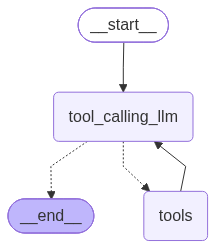

In [19]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 2 recent AI news for Machine Learning and then add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 2 recent AI news for Machine Learning and then add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_b12d31e2-c076-422c-a95f-2cebfdca8dbc)
 Call ID: fc_b12d31e2-c076-422c-a95f-2cebfdca8dbc
  Args:
    query: latest AI news machine learning August 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Machine Learning & AI recent news | InformationWeek", "url": "https://www.informationweek.com/machine-learning-ai", "content": "byMary E. Shacklett\n\nAug 20, 2026\n\n4 Min Read\n\nA digital illustration of an AI workflow.Machine Learning & AI\n\nAI's real power: Transforming workflows, not just tasksAI's real power: Transforming workflows, not just tasks\n\nbyMatt Lyteson\n\nAug 19, 2026\n\n4 Min Read\n\nYa

In [22]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to **learn patterns from data** and make decisions or predictions **without being explicitly programmed for each specific task**.

---

## Core Idea

1. **Data → Model → Prediction**  
   - **Data**: A collection of examples (e.g., images, text, sensor readings).  
   - **Model**: A mathematical representation (e.g., a neural network, decision tree) whose parameters are adjusted during training.  
   - **Prediction/Decision**: Once trained, the model can infer outputs for new, unseen inputs.

2. **Learning Process**  
   - **Training**: The model iteratively updates its parameters to minimize a loss (error) on the training data.  
   - **Evaluatio

### Agent Memory
#### Aim
Lets introduce Agent With Memory

In [23]:
messages=graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================

5 + 8 = 13.


In [24]:
messages=[HumanMessage(content="Divide that by 5")]
messages=graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

I’m not sure which value you’d like to divide by 5. Could you let me know the number (or result) you’d like to use?


#### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

In [25]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="openai/gpt-oss-120b")
llm_with_tools = llm.bind_tools(tools)

In [26]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")

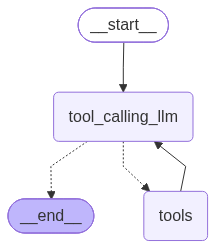

In [27]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

# View
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [28]:
## Specify the thread

config={"configurable":{"thread_id":"1"}}
# Specify an input
messages = [HumanMessage(content="Add 12 and 13.")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_5098d396-63e2-45ca-81c3-ee3bba0f9cee)
 Call ID: fc_5098d396-63e2-45ca-81c3-ee3bba0f9cee
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.


In [29]:
messages = [HumanMessage(content="add that number to 25")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_5098d396-63e2-45ca-81c3-ee3bba0f9cee)
 Call ID: fc_5098d396-63e2-45ca-81c3-ee3bba0f9cee
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (fc_c9528dcb-1701-401c-862b-8c9bf238970d)
 Call ID: fc_c9528dcb-1701-401c-862b-8c9bf238970d
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ===========

In [30]:
messages = [HumanMessage(content="then multiplty that number by 2")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_5098d396-63e2-45ca-81c3-ee3bba0f9cee)
 Call ID: fc_5098d396-63e2-45ca-81c3-ee3bba0f9cee
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (fc_c9528dcb-1701-401c-862b-8c9bf238970d)
 Call ID: fc_c9528dcb-1701-401c-862b-8c9bf238970d
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ===========